# COVID-19 Time-Series Analysis: Singapore vs USA

## Objective
This project analyzes COVID-19 case data in Singapore to understand how the outbreak evolved over time. It examines cumulative growth, daily case patterns, and changes over time using time-series techniques.

A comparative analysis with the USA is included to provide context and highlight differences in scale and variability between the two countries.

## Libraries Used

In [10]:
# Import required libraries

import pandas as pd          # For data loading, cleaning, and manipulation
import matplotlib.pyplot as plt   # For creating data visualizations (charts)
import os                    # For handling file paths and creating folders (e.g. visuals/)

# Output Directory Setup

In [11]:
# Set base directory for saving all visual outputs
base_path = "/workspaces/covid-analysis/visuals"

# Create directory if it does not already exist
os.makedirs(base_path, exist_ok=True)

## Data Loading

The dataset is sourced from Our World in Data (OWID), which provides comprehensive and regularly updated COVID-19 data across countries.

We load the dataset directly from the OWID GitHub repository for analysis.

In [12]:

# Load COVID-19 dataset from OWID
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

# Preview dataset
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


## Data Cleaning

We clean and transform the dataset to ensure consistency and usability for analysis.
This includes handling missing values and formatting date columns.

In [13]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# Handle missing values if any
df = df.fillna(0)

## Cumulative Case Trends

This chart shows the overall growth of COVID-19 cases over time in Singapore.

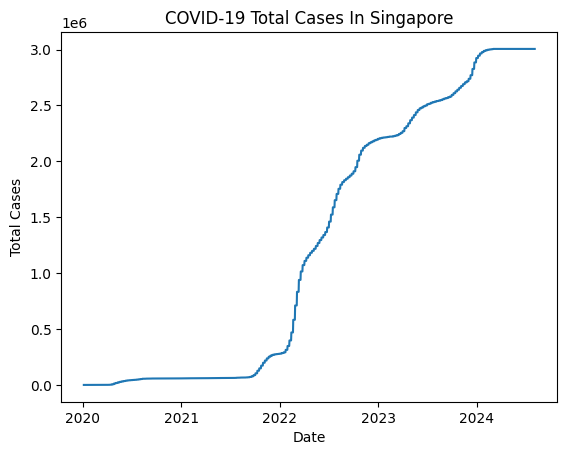

In [14]:
# Filter dataset for Singapore only
sg = df[df["location"] == "Singapore"]

# Create a new blank chart
plt.figure()

# Plot the total cases against the date
plt.plot(sg["date"], sg["total_cases"])

# Set the title and axis labels
plt.title("COVID-19 Total Cases In Singapore")
plt.xlabel("Date")
plt.ylabel("Total Cases")

# Save the chart as an image file to the specified path
plt.savefig(f"{base_path}/sg_total_cases.png")

# Display the chart on screen
plt.show()

## Daily Case Patterns

This chart highlights daily reported cases and short-term fluctuations.

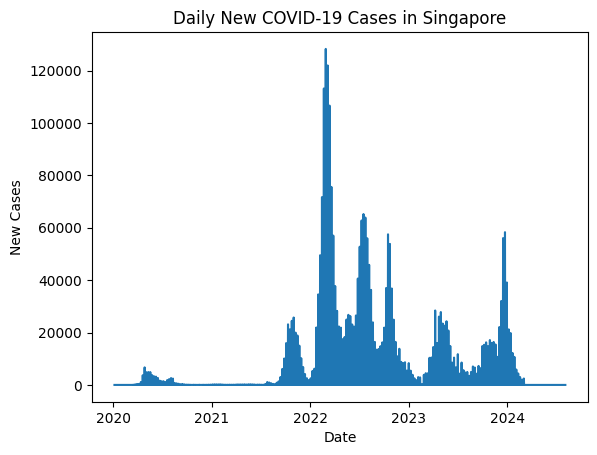

In [15]:
# Replace any missing data (NaN) with 0 to prevent gaps in the chart
sg["new_cases"] = sg["new_cases"].fillna(0)

# Create a new chart
plt.figure()

# Plot daily new cases against the date
plt.plot(sg["date"], sg["new_cases"])

# Add title and labels to the chart
plt.title("Daily New COVID-19 Cases in Singapore")
plt.xlabel("Date")
plt.ylabel("New Cases")

# Save the chart as a raw image file
plt.savefig(f"{base_path}/sg_daily_cases_raw.png")

# Display the finished chart
plt.show()

## Smoothed Daily Case Trends

Daily case data can be highly volatile due to reporting delays and short-term fluctuations. 

To better understand the underlying pattern, we apply a 7-day moving average to smooth th

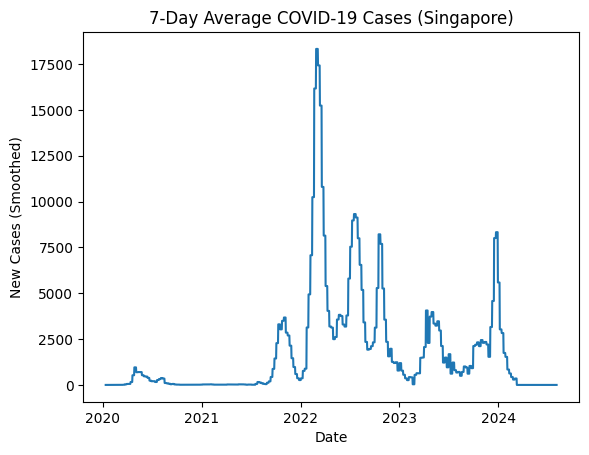

In [16]:
# Calculate the 7-day rolling average to smooth out daily spikes
sg["new_cases_smooth"] = sg["new_cases"].rolling(7).mean()

# Create a new chart
plt.figure()

# Plot the smoothed data over time
plt.plot(sg["date"], sg["new_cases_smooth"])

# Set chart title and axis labels
plt.title("7-Day Average COVID-19 Cases (Singapore)")
plt.xlabel("Date")
plt.ylabel("New Cases (Smoothed)")

# Save the chart as an image file
plt.savefig(f"{base_path}/sg_daily_cases_smoothed.png")

# Display the chart
plt.show()

## COVID-19 Case Comparison: Singapore vs United States

This chart compares cumulative COVID-19 cases between Singapore and the United States over time.

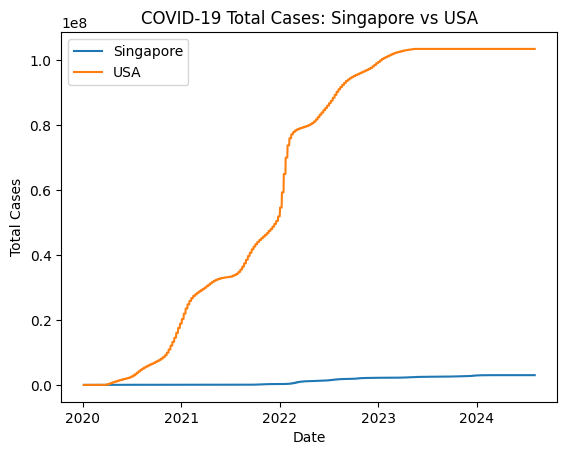

In [19]:
# Extract US data from the main list
us = df[df["location"] == "United States"]

# Convert the date text into a format the computer understands as time
us["date"] = pd.to_datetime(us["date"])

# Create a new blank chart
plt.figure()

# Draw the line for Singapore
plt.plot(sg["date"], sg["total_cases"], label="Singapore")

# Draw the line for USA
plt.plot(us["date"], us["total_cases"], label="USA")

# Show the box that explains which color is which country
plt.legend()

# Label the chart and the axes
plt.title("COVID-19 Total Cases: Singapore vs USA")
plt.xlabel("Date")
plt.ylabel("Total Cases")

# Save the chart as an image file
plt.savefig(f"{base_path}/comparison.png")

# Display the finished chart
plt.show()

## Comparison: Singapore vs United States

To better understand Singapore’s COVID-19 trend, it is useful to compare it with the United States.

### Key Observations

- The United States shows a much steeper increase in total cases, indicating a larger and faster-spreading outbreak.
- Singapore’s case growth is more gradual, suggesting better control over the spread.
- The gap between the two countries increases over time, highlighting the difference in outbreak scale.

### Interpretation

These differences are likely influenced by factors such as population size, government response, and how each country managed the outbreak.

### Insight

This comparison shows that COVID-19 trends can vary greatly between countries. Looking at Singapore alone is not enough—comparison helps provide context and deeper understanding.

### Conclusion

By comparing countries, we move beyond just observing data to understanding what drives the differences in outcomes.

## Key Insights

- Singapore went through several waves of COVID-19, with periods of increase followed by control.
- Daily case numbers can be very uneven, but using a 7-day average helps show the real trend more clearly.
- Compared to the United States, Singapore had much lower total cases, suggesting better control of the outbreak.
- Overall, this analysis shows that smoothing data and making comparisons help us understand trends more clearly.